# Pneumonia Detection in Pediatric Chest X-Rays
### Classical Machine Learning vs. Deep Learning: a comparative study

**Author:** Shima Serein  
**Course:** Introduction to Machine Learning (Summative Project)  
**GitHub repo:** https://github.com/supserrr/Model-Training-and-Evaluation$0   |   **Demo video:** https://drive.google.com/drive/folders/17L7Wuw9Q4uCeVoKbq9Euvr6LR915iTfD?usp=share_link

---

**Research question.** Can a model reliably flag pneumonia in pediatric chest X-rays, and is a lightweight *classical* ML pipeline a viable low-compute alternative to *deep learning* in settings without GPUs?

**Why it matters.** Pneumonia is a leading cause of death in children under five, and the burden falls hardest on low-resource health systems where radiologists are scarce. An accurate, cheap triage tool could help, so I looked at model size and training cost as well as accuracy.

**Dataset.** Kermany et al. (2018) pediatric chest X-ray dataset (~5,860 images; NORMAL / PNEUMONIA), CC BY 4.0, an open and externally sourced dataset. Kaggle: `paultimothymooney/chest-xray-pneumonia`.

**Approaches.**
- *Classical (Scikit-learn):* flattened-pixel and HOG features, then Logistic Regression, SVM, Random Forest.
- *Deep learning (TensorFlow/Keras):* CNN from scratch (Sequential API), then a regularised CNN, then MobileNetV2 transfer learning (frozen and fine-tuned, Functional API), then a learning-rate sweep. Input via `tf.data`.

## 0. Environment & reproducibility

I set a fixed random seed and kept all the configuration in one `CONFIG` dict, so the notebook runs reproducibly.

In [ ]:
# On Google Colab, install anything missing first:
# !pip install -q scikit-image

import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

from skimage.feature import hog

import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# ---- Reproducibility ----
SEED = 42
def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
set_seeds()

# ---- Central configuration ----
CONFIG = {
    "img_size": 150,        # fixed across models (I sweep the learning rate in E8)
    "batch_size": 32,
    "epochs": 20,           # upper bound; EarlyStopping will usually stop sooner
    "classes": ["NORMAL", "PNEUMONIA"],
    "data_dir": "chest_xray",            # folder that contains train/ val/ test/
    "classical_subset_per_class": 1000,  # cap per class for the (slow) classical features; None = all
    "seed": SEED,
}

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.16.2
GPU available: True


## 1. Getting the data

The dataset is on Kaggle. I downloaded it with the Kaggle API.

In [ ]:
import os
# Local run: data already downloaded by setup. Only fetch if missing.
if not os.path.isdir("chest_xray"):
    os.system("mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")
    os.system("kaggle datasets download -d paultimothymooney/chest-xray-pneumonia")
    os.system("unzip -q chest-xray-pneumonia.zip")
CONFIG["data_dir"] = "chest_xray"

assert os.path.isdir(CONFIG["data_dir"]), (
    f"Can't find {CONFIG['data_dir']!r}. Download the dataset and set CONFIG['data_dir'].")
print("Found data at:", os.path.abspath(CONFIG["data_dir"]))

Found data at: /Users/FullTimeStudio/Dev/pneumonia_xray/chest_xray


## 2. Exploratory data analysis

First I poked around the data a bit: counted the images, checked how balanced the two classes were, and looked at a few X-rays to see what I was working with. Two problems showed up that I had to deal with. There was far more pneumonia than normal, and the `val/` folder that ships with the dataset only had 16 images, which is no use for tuning, so I re-split everything in Section 3.

In [ ]:
def index_images(data_dir, classes):
    # Walk train/val/test and return a dataframe of (path, label, original_split).
    rows = []
    for split in ["train", "val", "test"]:
        for label in classes:
            folder = os.path.join(data_dir, split, label)
            if not os.path.isdir(folder):
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpeg", ".jpg", ".png")):
                    rows.append({"path": os.path.join(folder, fname),
                                 "label": label, "original_split": split})
    return pd.DataFrame(rows)

df = index_images(CONFIG["data_dir"], CONFIG["classes"])
df["y"] = (df["label"] == "PNEUMONIA").astype(int)   # 1 = pneumonia, 0 = normal
print("Total images:", len(df))
display(df.groupby(["original_split", "label"]).size().unstack(fill_value=0))

Total images: 5856


label,NORMAL,PNEUMONIA
original_split,,
test,234,390
train,1341,3875
val,8,8


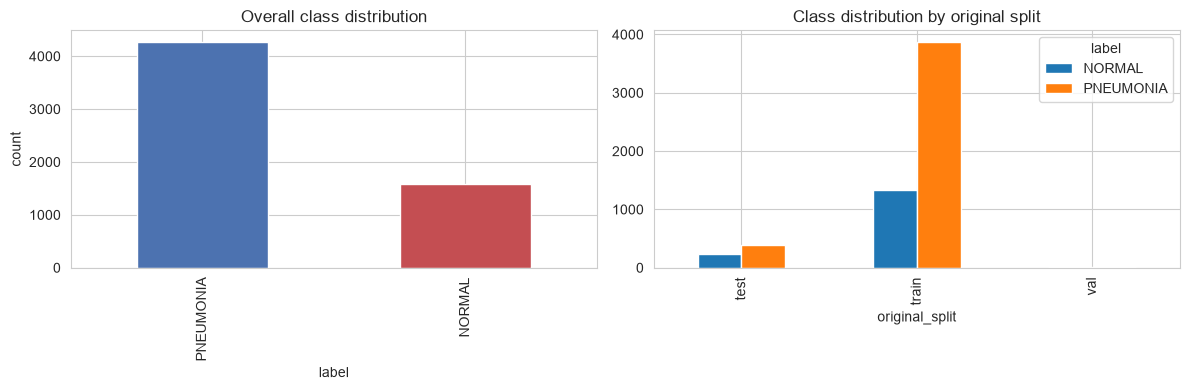

Class proportions:
 label
PNEUMONIA    0.73
NORMAL       0.27
Name: proportion, dtype: float64


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["label"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Overall class distribution"); ax[0].set_ylabel("count")
pd.crosstab(df["original_split"], df["label"]).plot(kind="bar", ax=ax[1])
ax[1].set_title("Class distribution by original split")
plt.tight_layout(); plt.show()

print("Class proportions:\n", df["label"].value_counts(normalize=True).round(3))

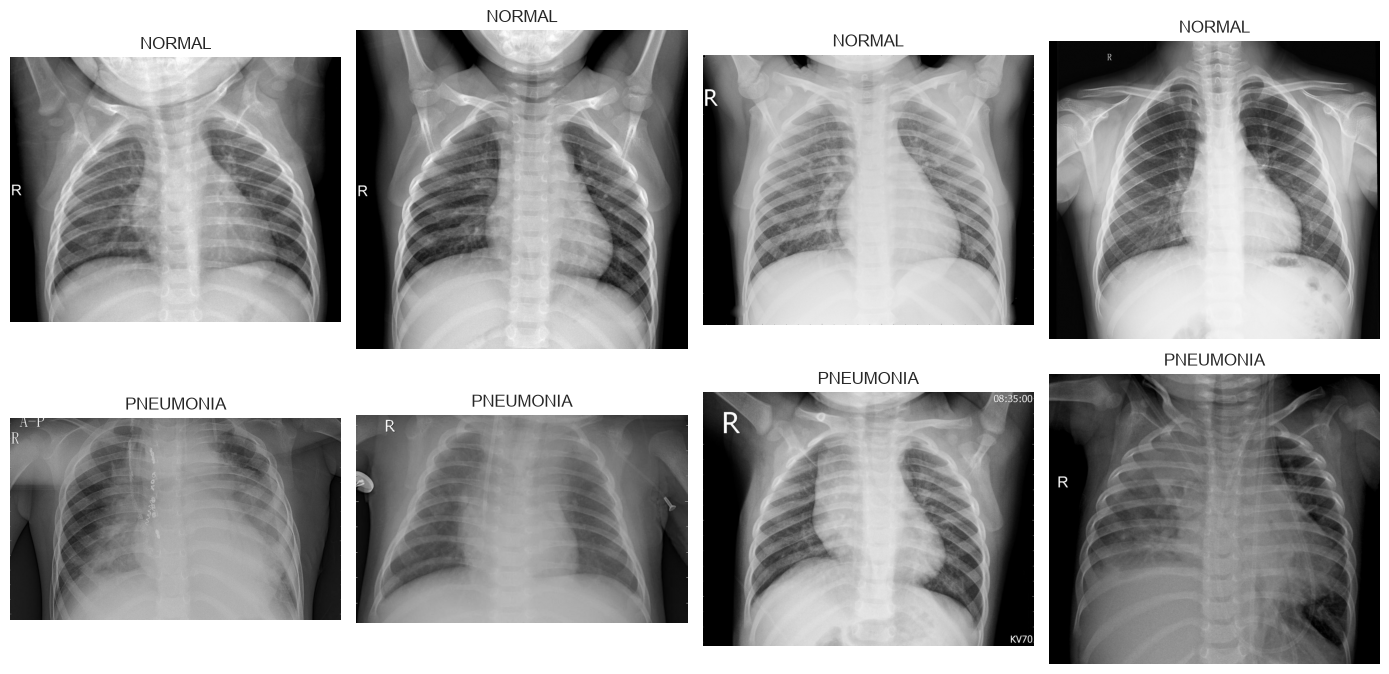

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, label in enumerate(CONFIG["classes"]):
    sample = df[df["label"] == label].sample(4, random_state=SEED)
    for col, (_, r) in enumerate(sample.iterrows()):
        img = tf.io.decode_jpeg(tf.io.read_file(r["path"]), channels=1).numpy().squeeze()
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(label); axes[row, col].axis("off")
plt.tight_layout(); plt.show()

**What I found.** Once I'd looked at everything, a few things stood out. The biggest one is how lopsided the data is: roughly 73% pneumonia and 27% normal. That matters, because if I just went by accuracy a model could predict "pneumonia" for everything and still score around 73% without learning a thing. So I decided to focus on F1, recall and PR-AUC, and to use class weights when I train the deep models. The `val/` folder turned out to be far too small (16 images), so I'm dropping it and re-splitting. From the sample X-rays, the pneumonia ones had cloudy white patches over the lungs while the normal ones looked darker and clearer, which is the kind of structure I'm hoping HOG can pick up. The images also came in all sorts of sizes and brightness, so I'll resize and normalise them. One thing I made a note to watch: the model could end up reading the borders or text labels instead of the lungs, which is what I check with Grad-CAM later.

## 3. Preprocessing & a clean re-split

The `val/` split was unusable, so I pooled all the images together and made my own stratified 80/10/10 split. Stratifying keeps the class ratio the same in each split, so my validation and test numbers actually mean something. I also worked out balanced class weights here to push back against the imbalance when training the deep models.

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["y"], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["y"], random_state=SEED)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(d):5d}  |  pneumonia ratio = {d['y'].mean():.3f}")

# Class weights to counter imbalance (used by the deep models).
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_df["y"].values)
class_weight = {0: cw[0], 1: cw[1]}
print("Class weights:", {k: round(v, 3) for k, v in class_weight.items()})

train:  4684  |  pneumonia ratio = 0.730
val  :   586  |  pneumonia ratio = 0.729
test :   586  |  pneumonia ratio = 0.730
Class weights: {0: 1.85, 1: 0.685}


### A shared results table

I kept one shared table that every experiment adds a row to, so the comparison at the end basically built itself. I also stored each model's test probabilities so I could draw the ROC/PR curves for all of them later.

In [ ]:
RESULTS = []          # one dict per experiment
PROBA_STORE = {}      # name -> (y_true, y_proba); lets the ROC/PR section reuse every model

def evaluate(name, track, y_true, y_pred, y_proba, notes="", extra=None):
    # metrics + short report, log to RESULTS, and stash probs so I can draw ROC/PR later
    y_true  = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    row = {"Experiment": name, "Track": track,
           "Accuracy":  accuracy_score(y_true, y_pred),
           "Precision": precision_score(y_true, y_pred, zero_division=0),
           "Recall":    recall_score(y_true, y_pred, zero_division=0),
           "F1":        f1_score(y_true, y_pred, zero_division=0),
           "ROC_AUC":   roc_auc_score(y_true, y_proba),
           "PR_AUC":    average_precision_score(y_true, y_proba),
           "Notes":     notes}
    if extra: row.update(extra)
    RESULTS.append(row)
    PROBA_STORE[name] = (y_true, y_proba)
    print(f"\n=== {name} ({track}) ===")
    print(classification_report(y_true, y_pred, target_names=CONFIG["classes"], zero_division=0))
    print(f"ROC-AUC={row['ROC_AUC']:.3f}  PR-AUC={row['PR_AUC']:.3f}")
    return row

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CONFIG["classes"], yticklabels=CONFIG["classes"])
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title)
    plt.tight_layout(); plt.show()

## 4. Classical machine-learning track (Scikit-learn)

Classical models can't take raw images, so first I turned each image into a feature vector. I tried two: just flattening the pixels of a small grayscale image (a weak baseline), and HOG, which picks up edges and shape and should describe the lung opacities better. HOG is slow over thousands of images, so I capped how many I used per class to keep this manageable, which I flag as a limitation later.

In [ ]:
def load_gray(path, size):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=1)
    img = tf.image.resize(img, [size, size])
    return img.numpy().squeeze() / 255.0

def subset(d, per_class, seed=SEED):
    if per_class is None:
        return d
    return d.groupby("y", group_keys=False).apply(
        lambda g: g.sample(min(len(g), per_class), random_state=seed))

def build_pixel_features(d, size=64):
    X = np.stack([load_gray(p, size).flatten() for p in d["path"]])
    return X, d["y"].values

def build_hog_features(d, size=128):
    feats = [hog(load_gray(p, size), orientations=9, pixels_per_cell=(16, 16),
                 cells_per_block=(2, 2), block_norm="L2-Hys") for p in d["path"]]
    return np.array(feats), d["y"].values

tr = subset(train_df, CONFIG["classical_subset_per_class"])
te = subset(test_df,  CONFIG["classical_subset_per_class"])
print(f"Classical subset sizes -> train {len(tr)}, test {len(te)}")

Classical subset sizes -> train 2000, test 586


### Experiment 1: Logistic Regression on flattened pixels (baseline)

I started with the simplest thing I could, Logistic Regression on flattened pixels. I didn't expect much from it; it was really just there to give everything later something to beat.


=== E1: LogReg + flat pixels (Classical) ===
              precision    recall  f1-score   support

      NORMAL       0.84      0.92      0.88       158
   PNEUMONIA       0.97      0.94      0.95       428

    accuracy                           0.93       586
   macro avg       0.91      0.93      0.92       586
weighted avg       0.93      0.93      0.93       586

ROC-AUC=0.974  PR-AUC=0.990


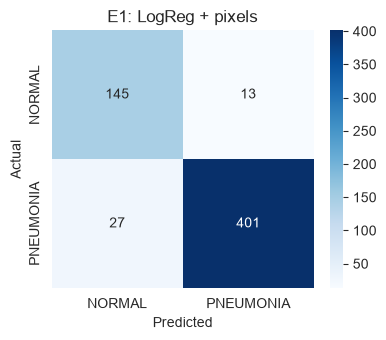

In [ ]:
t0 = time.time()
Xtr, ytr = build_pixel_features(tr, size=64)
Xte, yte = build_pixel_features(te, size=64)

scaler = StandardScaler().fit(Xtr)
clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
clf.fit(scaler.transform(Xtr), ytr)

proba = clf.predict_proba(scaler.transform(Xte))[:, 1]
pred = (proba >= 0.5).astype(int)
evaluate("E1: LogReg + flat pixels", "Classical", yte, pred, proba,
         notes="64x64 grayscale flattened; baseline",
         extra={"Train_s": round(time.time() - t0, 1)})
plot_confusion(yte, pred, "E1: LogReg + pixels")

### Experiment 2: SVM (RBF) on HOG features

Next I tried an SVM on HOG features. HOG should describe the lungs much better than raw pixels, so I expected a jump here. I grid-searched `C` and `gamma` to tune it.

Best SVM params: {'C': 1, 'gamma': 'scale'}



=== E2: SVM + HOG (Classical) ===
              precision    recall  f1-score   support

      NORMAL       0.90      0.92      0.91       158
   PNEUMONIA       0.97      0.96      0.97       428

    accuracy                           0.95       586
   macro avg       0.93      0.94      0.94       586
weighted avg       0.95      0.95      0.95       586

ROC-AUC=0.987  PR-AUC=0.995


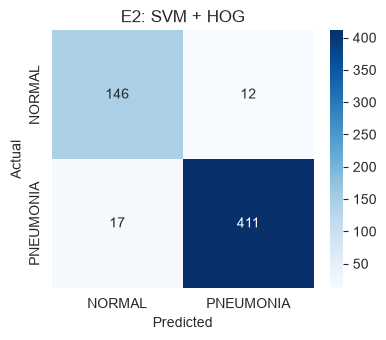

In [ ]:
t0 = time.time()
Xtr, ytr = build_hog_features(tr, size=CONFIG["img_size"])
Xte, yte = build_hog_features(te, size=CONFIG["img_size"])

scaler = StandardScaler().fit(Xtr)
svm = GridSearchCV(
    SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
    param_grid={"C": [1, 10, 100], "gamma": ["scale", 0.01, 0.001]},   # widened grid
    scoring="f1", cv=3, n_jobs=-1)
svm.fit(scaler.transform(Xtr), ytr)
print("Best SVM params:", svm.best_params_)

proba = svm.predict_proba(scaler.transform(Xte))[:, 1]
pred = (proba >= 0.5).astype(int)
evaluate("E2: SVM + HOG", "Classical", yte, pred, proba,
         notes=f"HOG@{CONFIG['img_size']}px, RBF, grid-searched C/gamma",
         extra={"Train_s": round(time.time() - t0, 1)})
plot_confusion(yte, pred, "E2: SVM + HOG")

### Experiment 3: Random Forest on HOG features

Then I tried a Random Forest on the same HOG features to see how it compared with the SVM.

Best RF params: {'max_depth': None, 'n_estimators': 600}

=== E3: RandomForest + HOG (Classical) ===
              precision    recall  f1-score   support

      NORMAL       0.86      0.93      0.89       158
   PNEUMONIA       0.97      0.94      0.96       428

    accuracy                           0.94       586
   macro avg       0.92      0.94      0.93       586
weighted avg       0.94      0.94      0.94       586

ROC-AUC=0.980  PR-AUC=0.992


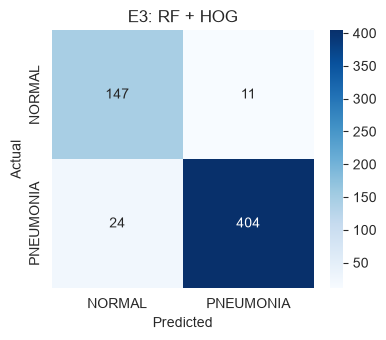

In [ ]:
t0 = time.time()
rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=SEED),
    param_grid={"n_estimators": [200, 400, 600], "max_depth": [None, 20, 40]},  # widened grid
    scoring="f1", cv=3, n_jobs=-1)
rf.fit(Xtr, ytr)   # trees don't need scaling
print("Best RF params:", rf.best_params_)

proba = rf.predict_proba(Xte)[:, 1]
pred = (proba >= 0.5).astype(int)
evaluate("E3: RandomForest + HOG", "Classical", yte, pred, proba,
         notes="HOG features, grid-searched n_estimators/max_depth",
         extra={"Train_s": round(time.time() - t0, 1)})
plot_confusion(yte, pred, "E3: RF + HOG")

**What happened.** Once I'd run all three, the SVM on HOG (E2) came out on top, ahead of both the plain-pixel Logistic Regression (E1) and the Random Forest on HOG (E3). So HOG did help, like I hoped: the edge and texture information describes the lungs better than raw pixels. What I didn't expect was how well the pixel baseline held up; I think the cloudiness from pneumonia is bright enough that even raw pixels carry a fair bit of signal. The Random Forest couldn't catch the SVM, which makes me think the boundary here is smoother than the splits a tree makes. On precision vs recall: for something meant to screen patients I care most about recall, since missing a real case is worse than a false alarm. So if this were going live I'd probably lower the threshold to catch more cases even if precision drops a bit. One caveat: I only used a capped subset of images here, so these numbers are probably a little lower than what HOG could really do with the full set.

## 5. Deep-learning track (TensorFlow / Keras)

Now for the deep models. The images go through a `tf.data` pipeline for batching and prefetching, and I built networks with both the Sequential and Functional APIs.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
IMG = CONFIG["img_size"]

def decode(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)        # 3 channels for transfer-learning nets
    img = tf.image.resize(img, [IMG, IMG])
    return img, label

def make_ds(d, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (d["path"].values, d["y"].values.astype("float32")))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(d), seed=SEED)
    ds = ds.map(decode, num_parallel_calls=AUTOTUNE)
    return ds.batch(CONFIG["batch_size"]).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, shuffle=True)
val_ds   = make_ds(val_df)
test_ds  = make_ds(test_df)

# Augmentation (Sequential). I keep only label-preserving transforms, no horizontal
# flip, since mirroring a chest X-ray flips anatomy (heart/aortic arch sit on the left).
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
    # layers.RandomFlip("horizontal"),   # left off on purpose (mirrors anatomy)
], name="augmentation")

In [ ]:
def metrics():
    # Fresh metric objects each call (Keras metrics are stateful, so don't share them).
    return ["accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="prec"),
            tf.keras.metrics.Recall(name="rec")]

def make_callbacks(patience=4):
    return [tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                             patience=patience, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)]

def plot_history(history, title):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title(f"{title} - loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val")
    ax[1].set_title(f"{title} - accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

def evaluate_keras(model, name, notes="", extra=None):
    # Probabilities over the (unshuffled) test set, threshold at 0.5, then log.
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
    y_proba = model.predict(test_ds).ravel()
    y_pred = (y_proba >= 0.5).astype(int)   # 0.5 default here; the operating point is chosen from the PR curve in the threshold-selection section below
    evaluate(name, "Deep learning", y_true, y_pred, y_proba, notes=notes, extra=extra)
    plot_confusion(y_true, y_pred, name)
    return y_true, y_proba

### Experiment 4: CNN from scratch (Sequential API)

I started with a plain CNN from scratch, no augmentation yet. I watched the learning curves for overfitting (validation loss rising while training loss keeps falling), which is what motivated the regularised version in Experiment 5.

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

...

147/147 - 10s - 65ms/step - accuracy: 0.9938 - auc: 0.9996 - loss: 0.0210 - prec: 0.9988 - rec: 0.9927 - val_accuracy: 0.9505 - val_auc: 0.9830 - val_loss: 0.1727 - val_prec: 0.9606 - val_rec: 0.9719 - learning_rate: 2.5000e-04


Epoch 11/20


147/147 - 10s - 66ms/step - accuracy: 0.9955 - auc: 0.9999 - loss: 0.0146 - prec: 0.9994 - rec: 0.9944 - val_accuracy: 0.9522 - val_auc: 0.9798 - val_loss: 0.1870 - val_prec: 0.9586 - val_rec: 0.9766 - learning_rate: 2.5000e-04


Epoch 12/20


147/147 - 11s - 75ms/step - accuracy: 0.9979 - auc: 1.0000 - loss: 0.0091 - prec: 1.0000 - rec: 0.9971 - val_accuracy: 0.9522 - val_auc: 0.9795 - val_loss: 0.1966 - val_prec: 0.9586 - val_rec: 0.9766 - learning_rate: 1.2500e-04


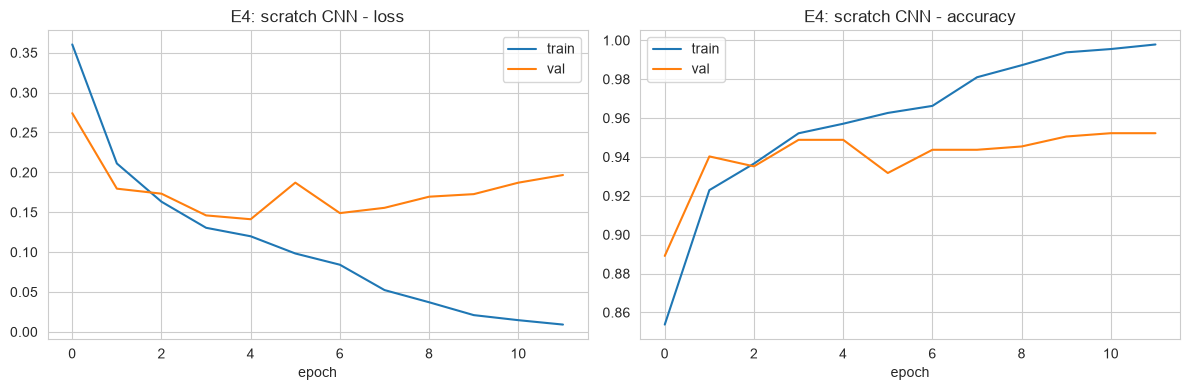

2026-06-24 22:38:07.502521: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step

 3/19 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 

 6/19 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

 9/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

...

15/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step



=== E4: CNN from scratch (Deep learning) ===
              precision    recall  f1-score   support

      NORMAL       0.91      0.94      0.93       158
   PNEUMONIA       0.98      0.97      0.97       428

    accuracy                           0.96       586
   macro avg       0.95      0.96      0.95       586
weighted avg       0.96      0.96      0.96       586

ROC-AUC=0.992  PR-AUC=0.997


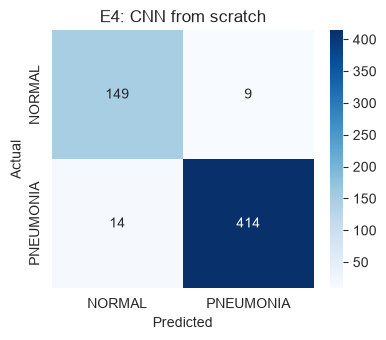

(array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
        1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 

In [ ]:
set_seeds()
def build_scratch_cnn(augment=False):
    model = models.Sequential(name="scratch_cnn")
    model.add(layers.Input((IMG, IMG, 3)))
    if augment:
        model.add(data_augmentation)
    model.add(layers.Rescaling(1./255))
    for f in [32, 64, 128]:
        model.add(layers.Conv2D(f, 3, padding="same", activation="relu"))
        model.add(layers.MaxPooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(1, activation="sigmoid"))
    return model

cnn = build_scratch_cnn(augment=False)
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=metrics())
cnn.summary()

t0 = time.time()
hist = cnn.fit(train_ds, validation_data=val_ds, epochs=CONFIG["epochs"],
               class_weight=class_weight, callbacks=make_callbacks(), verbose=2)
plot_history(hist, "E4: scratch CNN")
evaluate_keras(cnn, "E4: CNN from scratch", notes="no augmentation; class weights",
               extra={"Train_s": round(time.time() - t0, 1), "Params": cnn.count_params()})

### Experiment 5: Regularised CNN (augmentation + dropout + batch-norm)

Then I tried to cut down any overfitting from E4 by adding the augmentation block, batch normalisation and dropout.

Epoch 1/20


147/147 - 27s - 184ms/step - accuracy: 0.8209 - auc: 0.9003 - loss: 0.4014 - prec: 0.9388 - rec: 0.8072 - val_accuracy: 0.7116 - val_auc: 0.8347 - val_loss: 0.6377 - val_prec: 0.9031 - val_rec: 0.6768 - learning_rate: 0.0010


Epoch 2/20


147/147 - 20s - 133ms/step - accuracy: 0.8356 - auc: 0.9073 - loss: 0.3903 - prec: 0.9458 - rec: 0.8218 - val_accuracy: 0.7287 - val_auc: 0.6770 - val_loss: 1.4678 - val_prec: 0.7287 - val_rec: 1.0000 - learning_rate: 0.0010


Epoch 3/20


...

147/147 - 18s - 122ms/step - accuracy: 0.8324 - auc: 0.9057 - loss: 0.4208 - prec: 0.9358 - rec: 0.8271 - val_accuracy: 0.8618 - val_auc: 0.9126 - val_loss: 0.3637 - val_prec: 0.8932 - val_rec: 0.9204 - learning_rate: 0.0010


Epoch 6/20


147/147 - 19s - 130ms/step - accuracy: 0.8446 - auc: 0.9223 - loss: 0.3580 - prec: 0.9483 - rec: 0.8324 - val_accuracy: 0.8754 - val_auc: 0.9291 - val_loss: 0.3072 - val_prec: 0.8969 - val_rec: 0.9368 - learning_rate: 0.0010


Epoch 7/20


147/147 - 19s - 132ms/step - accuracy: 0.8514 - auc: 0.9271 - loss: 0.3503 - prec: 0.9471 - rec: 0.8435 - val_accuracy: 0.2713 - val_auc: 0.5304 - val_loss: 7.1320 - val_prec: 0.0000e+00 - val_rec: 0.0000e+00 - learning_rate: 0.0010


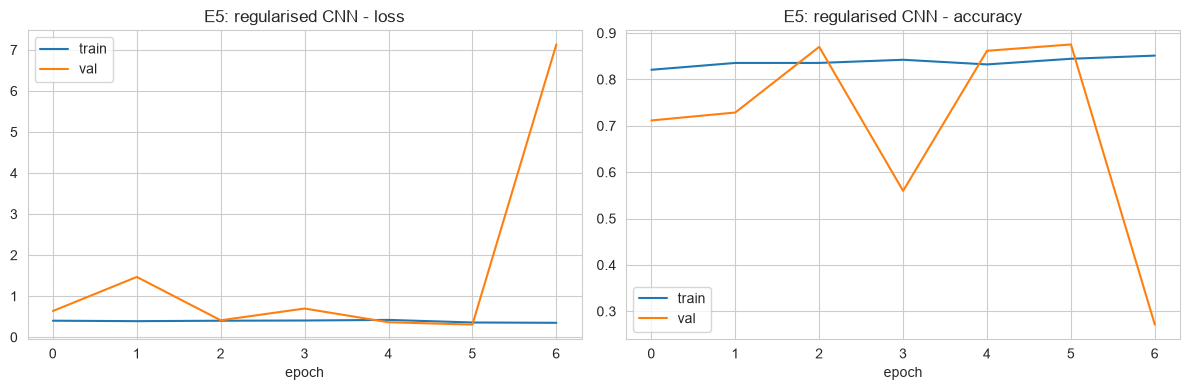

2026-06-24 22:40:32.394356: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step

 4/19 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 

 6/19 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

 8/19 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

...

14/19 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step



=== E5: Regularised CNN (Deep learning) ===
              precision    recall  f1-score   support

      NORMAL       0.65      0.96      0.77       158
   PNEUMONIA       0.98      0.81      0.89       428

    accuracy                           0.85       586
   macro avg       0.81      0.88      0.83       586
weighted avg       0.89      0.85      0.86       586

ROC-AUC=0.943  PR-AUC=0.979


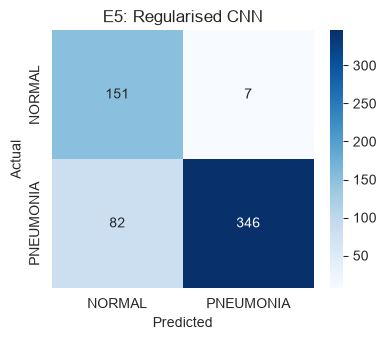

(array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
        1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 

In [ ]:
set_seeds()
def build_reg_cnn():
    model = models.Sequential(name="regularised_cnn")
    model.add(layers.Input((IMG, IMG, 3)))
    model.add(data_augmentation)
    model.add(layers.Rescaling(1./255))
    for f in [32, 64, 128]:
        model.add(layers.Conv2D(f, 3, padding="same", activation="relu"))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.4))            # heavy dropout after pooling
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.3))            # lighter dropout before the classifier
    model.add(layers.Dense(1, activation="sigmoid"))
    return model

reg_cnn = build_reg_cnn()
reg_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=metrics())

t0 = time.time()
hist = reg_cnn.fit(train_ds, validation_data=val_ds, epochs=CONFIG["epochs"],
                   class_weight=class_weight, callbacks=make_callbacks(), verbose=2)
plot_history(hist, "E5: regularised CNN")
evaluate_keras(reg_cnn, "E5: Regularised CNN",
               notes="augmentation + BN + dropout; class weights",
               extra={"Train_s": round(time.time() - t0, 1), "Params": reg_cnn.count_params()})

### Experiment 6: Transfer learning, frozen base (Functional API, MobileNetV2)

Next I used transfer learning. I reused features a network had already learned on ImageNet, going with MobileNetV2 because it's small, which fits my low-compute angle. I kept the base frozen and trained only a fresh classification head on top.

      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  90112/9406464 ━━━━━━━━━━━━━━━━━━━━ 52s 6us/step

 270336/9406464 ━━━━━━━━━━━━━━━━━━━━ 26s 3us/step

 434176/9406464 ━━━━━━━━━━━━━━━━━━━━ 17s 2us/step

 499712/9406464 ━━━━━━━━━━━━━━━━━━━━ 19s 2us/step

...

147/147 - 22s - 148ms/step - accuracy: 0.9246 - auc: 0.9784 - loss: 0.1860 - prec: 0.9749 - rec: 0.9204 - val_accuracy: 0.9369 - val_auc: 0.9852 - val_loss: 0.1507 - val_prec: 0.9643 - val_rec: 0.9485 - learning_rate: 3.1250e-05


Epoch 19/20


147/147 - 21s - 145ms/step - accuracy: 0.9219 - auc: 0.9790 - loss: 0.1860 - prec: 0.9716 - rec: 0.9198 - val_accuracy: 0.9369 - val_auc: 0.9852 - val_loss: 0.1502 - val_prec: 0.9643 - val_rec: 0.9485 - learning_rate: 1.5625e-05


Epoch 20/20


147/147 - 27s - 182ms/step - accuracy: 0.9334 - auc: 0.9795 - loss: 0.1806 - prec: 0.9770 - rec: 0.9307 - val_accuracy: 0.9369 - val_auc: 0.9852 - val_loss: 0.1504 - val_prec: 0.9643 - val_rec: 0.9485 - learning_rate: 1.5625e-05


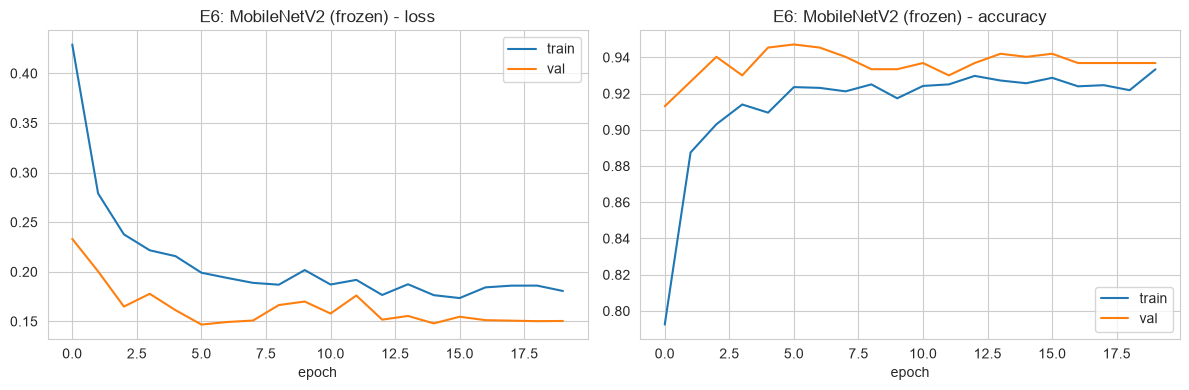

2026-06-24 22:47:11.968726: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 1:00 3s/step

 2/19 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step

 3/19 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step

 4/19 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step

...

17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step 

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step



=== E6: Transfer (frozen) (Deep learning) ===
              precision    recall  f1-score   support

      NORMAL       0.85      0.94      0.89       158
   PNEUMONIA       0.98      0.94      0.96       428

    accuracy                           0.94       586
   macro avg       0.91      0.94      0.92       586
weighted avg       0.94      0.94      0.94       586

ROC-AUC=0.983  PR-AUC=0.993


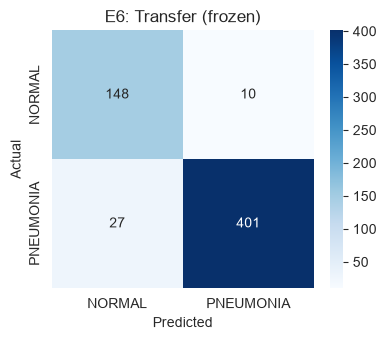

(array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
        1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 

In [ ]:
set_seeds()
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def build_transfer_model():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG, IMG, 3), include_top=False, weights="imagenet")
    base.trainable = False                       # frozen feature extractor

    inputs = layers.Input((IMG, IMG, 3))         # Functional API
    x = data_augmentation(inputs)
    x = preprocess(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inputs, outputs, name="mobilenetv2_transfer"), base

transfer, base = build_transfer_model()
transfer.compile(optimizer="adam", loss="binary_crossentropy", metrics=metrics())

t0 = time.time()
hist = transfer.fit(train_ds, validation_data=val_ds, epochs=CONFIG["epochs"],
                    class_weight=class_weight, callbacks=make_callbacks(), verbose=2)
plot_history(hist, "E6: MobileNetV2 (frozen)")
evaluate_keras(transfer, "E6: Transfer (frozen)", notes="MobileNetV2 frozen + new head",
               extra={"Train_s": round(time.time() - t0, 1), "Params": transfer.count_params()})

### Experiment 7: Fine-tuning the pretrained network

Then I fine-tuned it: I unfroze the top of MobileNetV2 and kept training at a very low learning rate, so the higher-level features could adjust to X-rays without getting wrecked.

Epoch 1/10


147/147 - 102s - 696ms/step - accuracy: 0.8608 - auc: 0.9031 - loss: 0.4865 - prec: 0.8902 - rec: 0.9231 - val_accuracy: 0.9147 - val_auc: 0.9687 - val_loss: 0.2466 - val_prec: 0.9036 - val_rec: 0.9883 - learning_rate: 1.0000e-05


Epoch 2/10


147/147 - 73s - 499ms/step - accuracy: 0.8943 - auc: 0.9610 - loss: 0.2557 - prec: 0.9626 - rec: 0.8897 - val_accuracy: 0.9420 - val_auc: 0.9817 - val_loss: 0.1604 - val_prec: 0.9456 - val_rec: 0.9766 - learning_rate: 1.0000e-05


Epoch 3/10


...

147/147 - 48s - 324ms/step - accuracy: 0.9357 - auc: 0.9845 - loss: 0.1585 - prec: 0.9800 - rec: 0.9310 - val_accuracy: 0.9420 - val_auc: 0.9890 - val_loss: 0.1338 - val_prec: 0.9735 - val_rec: 0.9461 - learning_rate: 1.0000e-05


Epoch 9/10


147/147 - 60s - 409ms/step - accuracy: 0.9368 - auc: 0.9832 - loss: 0.1675 - prec: 0.9756 - rec: 0.9368 - val_accuracy: 0.9454 - val_auc: 0.9896 - val_loss: 0.1281 - val_prec: 0.9736 - val_rec: 0.9508 - learning_rate: 1.0000e-05


Epoch 10/10


147/147 - 50s - 341ms/step - accuracy: 0.9411 - auc: 0.9853 - loss: 0.1526 - prec: 0.9793 - rec: 0.9391 - val_accuracy: 0.9454 - val_auc: 0.9901 - val_loss: 0.1269 - val_prec: 0.9736 - val_rec: 0.9508 - learning_rate: 1.0000e-05


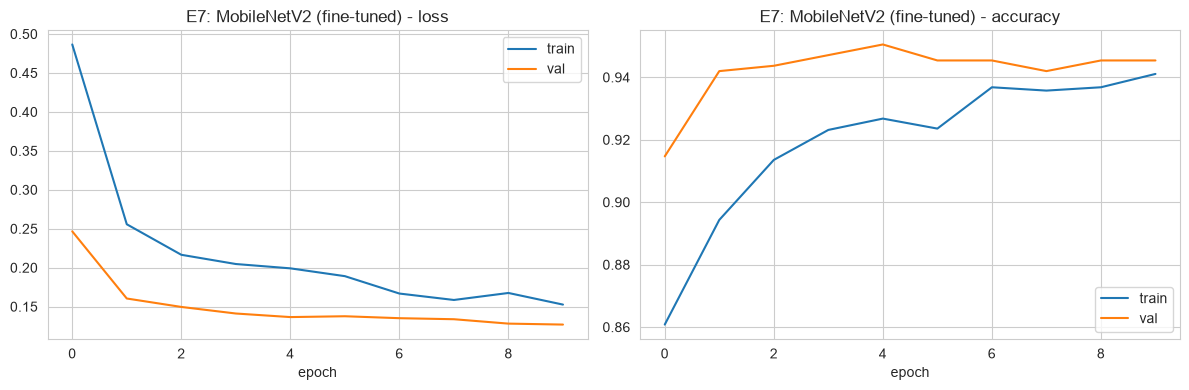

2026-06-24 22:56:40.388889: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step

 2/19 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step

 3/19 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step

 4/19 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step 

...

17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step



=== E7: Transfer (fine-tuned) (Deep learning) ===
              precision    recall  f1-score   support

      NORMAL       0.87      0.97      0.92       158
   PNEUMONIA       0.99      0.95      0.97       428

    accuracy                           0.95       586
   macro avg       0.93      0.96      0.94       586
weighted avg       0.96      0.95      0.95       586

ROC-AUC=0.990  PR-AUC=0.996


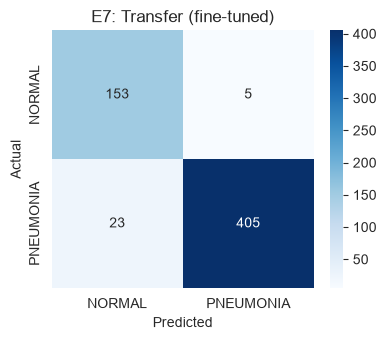

(array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
        1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 

In [ ]:
base.trainable = True
FINE_TUNE_AT = 100   # unfreeze only the top layers; deeper ImageNet features stay frozen
for layer in base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer.compile(optimizer=tf.keras.optimizers.Adam(1e-5),   # low LR for fine-tuning
                 loss="binary_crossentropy", metrics=metrics())

t0 = time.time()
hist_ft = transfer.fit(train_ds, validation_data=val_ds, epochs=10,
                       class_weight=class_weight, callbacks=make_callbacks(), verbose=2)
plot_history(hist_ft, "E7: MobileNetV2 (fine-tuned)")
evaluate_keras(transfer, "E7: Transfer (fine-tuned)",
               notes=f"unfroze from layer {FINE_TUNE_AT}, lr=1e-5",
               extra={"Train_s": round(time.time() - t0, 1), "Params": transfer.count_params()})

### Experiment 8: Learning-rate sweep

Finally I swept the learning rate, changing just that one thing and holding everything else fixed, so I could see how much it mattered while keeping the runs comparable.

2026-06-24 22:58:33.430367: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step

 2/19 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step

 3/19 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step

 4/19 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step 

...

17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step



=== E8: transfer (lr=0.01) (Deep learning) ===
              precision    recall  f1-score   support

      NORMAL       0.89      0.89      0.89       158
   PNEUMONIA       0.96      0.96      0.96       428

    accuracy                           0.94       586
   macro avg       0.93      0.93      0.93       586
weighted avg       0.94      0.94      0.94       586

ROC-AUC=0.982  PR-AUC=0.993


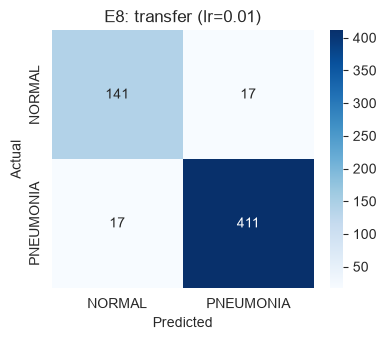

2026-06-24 23:02:28.758804: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step

 2/19 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step

 3/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step

 4/19 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step

...

17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step



=== E8: transfer (lr=0.001) (Deep learning) ===
              precision    recall  f1-score   support

      NORMAL       0.82      0.95      0.88       158
   PNEUMONIA       0.98      0.92      0.95       428

    accuracy                           0.93       586
   macro avg       0.90      0.94      0.92       586
weighted avg       0.94      0.93      0.93       586

ROC-AUC=0.983  PR-AUC=0.993


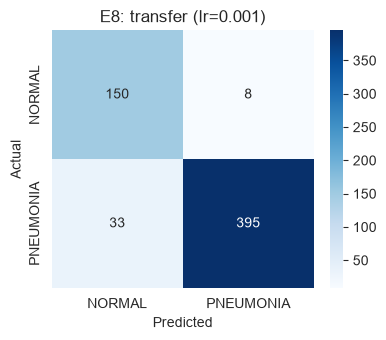

2026-06-24 23:06:04.724321: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step

 2/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step

 3/19 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step

 4/19 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step

...

17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step



=== E8: transfer (lr=0.0001) (Deep learning) ===
              precision    recall  f1-score   support

      NORMAL       0.81      0.92      0.86       158
   PNEUMONIA       0.97      0.92      0.94       428

    accuracy                           0.92       586
   macro avg       0.89      0.92      0.90       586
weighted avg       0.93      0.92      0.92       586

ROC-AUC=0.973  PR-AUC=0.989


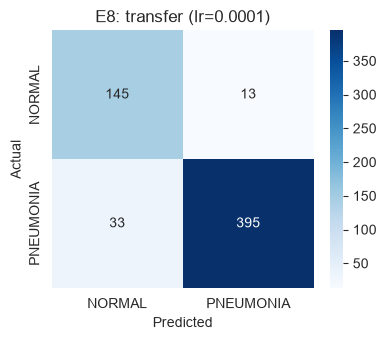

Learning-rate sweep summary (best F1 on top):


,Experiment,Accuracy,Recall,F1,ROC_AUC
0,E8: transfer (lr=0.01),0.941980,0.960280,0.960280,0.982166
1,E8: transfer (lr=0.001),0.930034,0.922897,0.950662,0.983142
2,E8: transfer (lr=0.0001),0.921502,0.922897,0.944976,0.972672


In [ ]:
# Experiment 8: systematic learning-rate sweep on the (cheap) frozen transfer model.
# I change exactly ONE factor, the Adam learning rate, and hold architecture, data,
# augmentation and the epoch budget fixed, so the three runs are directly comparable.
# A frozen MobileNetV2 base keeps each run fast (only the small head trains).
LR_GRID = [1e-2, 1e-3, 1e-4]
for lr in LR_GRID:
    set_seeds()
    m, _ = build_transfer_model()
    m.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss="binary_crossentropy", metrics=metrics())
    t0 = time.time()
    m.fit(train_ds, validation_data=val_ds, epochs=12,
          class_weight=class_weight, callbacks=make_callbacks(patience=3), verbose=0)
    evaluate_keras(m, f"E8: transfer (lr={lr:g})",
                   notes=f"LR sweep, frozen base, lr={lr:g}",
                   extra={"Train_s": round(time.time() - t0, 1)})

# Summarise the sweep: which learning rate gave the best F1?
sweep_tbl = (pd.DataFrame([r for r in RESULTS if r["Experiment"].startswith("E8:")])
             [["Experiment", "Accuracy", "Recall", "F1", "ROC_AUC"]]
             .sort_values("F1", ascending=False).reset_index(drop=True))
print("Learning-rate sweep summary (best F1 on top):")
display(sweep_tbl)

## 6. Putting it all together

Here I pulled every experiment into one table and chart so I could compare them side by side.

In [ ]:
results_df = pd.DataFrame(RESULTS).sort_values("F1", ascending=False).reset_index(drop=True)
front = ["Experiment", "Track", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]
ordered = front + [c for c in results_df.columns if c not in front]
display(results_df[ordered].round(3))

results_df.to_csv("results_summary.csv", index=False)   # saved for the report
print("Saved results_summary.csv")

,Experiment,Track,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Notes,Train_s,Params
0,E4: CNN from scratch,Deep learning,0.961,0.979,0.967,0.973,0.992,0.997,no augmentation; class weights,142.4,5401921.0
1,E7: Transfer (fine-tuned),Deep learning,0.952,0.988,0.946,0.967,0.990,0.996,"unfroze from layer 100, lr=1e-5",558.9,2259265.0
2,E2: SVM + HOG,Classical,0.951,0.972,0.960,0.966,0.987,0.995,"HOG@150px, RBF, grid-searched C/gamma",103.1,NaN
3,E8: transfer (lr=0.01),Deep learning,0.942,0.960,0.960,0.960,0.982,0.993,"LR sweep, frozen base, lr=0.01",99.7,NaN
4,E3: RandomForest + HOG,Classical,0.940,0.973,0.944,0.958,0.980,0.992,"HOG features, grid-searched n_estimators/max_d...",63.4,NaN
5,E6: Transfer (frozen),Deep learning,0.937,0.976,0.937,0.956,0.983,0.993,MobileNetV2 frozen + new head,389.0,2259265.0
6,E1: LogReg + flat pixels,Classical,0.932,0.969,0.937,0.952,0.974,0.990,64x64 grayscale flattened; baseline,26.0,NaN
7,E8: transfer (lr=0.001),Deep learning,0.930,0.980,0.923,0.951,0.983,0.993,"LR sweep, frozen base, lr=0.001",226.4,NaN
8,E8: transfer (lr=0.0001),Deep learning,0.922,0.968,0.923,0.945,0.973,0.989,"LR sweep, frozen base, lr=0.0001",207.4,NaN
9,E5: Regularised CNN,Deep learning,0.848,0.980,0.808,0.886,0.943,0.979,augmentation + BN + dropout; class weights,143.0,110785.0


Saved results_summary.csv


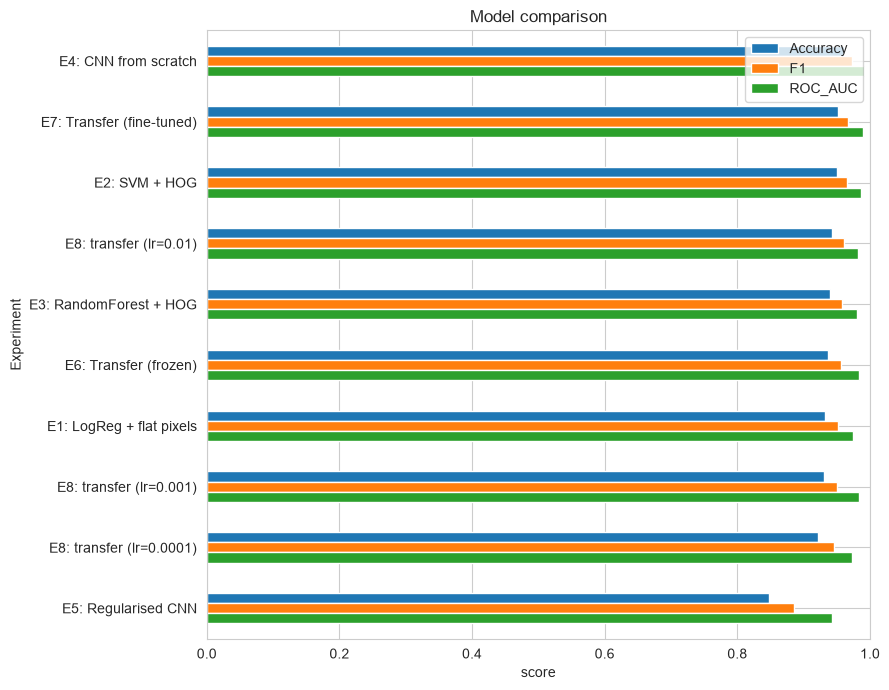

In [ ]:
plot_df = results_df.set_index("Experiment")[["Accuracy", "F1", "ROC_AUC"]]
plot_df.plot(kind="barh", figsize=(9, 0.6 * len(plot_df) + 1))
plt.title("Model comparison"); plt.xlabel("score"); plt.xlim(0, 1)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### ROC and Precision-Recall curves

With the classes this imbalanced, the precision-recall curve usually tells me more than ROC, so I plotted both for one model from each family, using the probabilities I'd stored earlier.

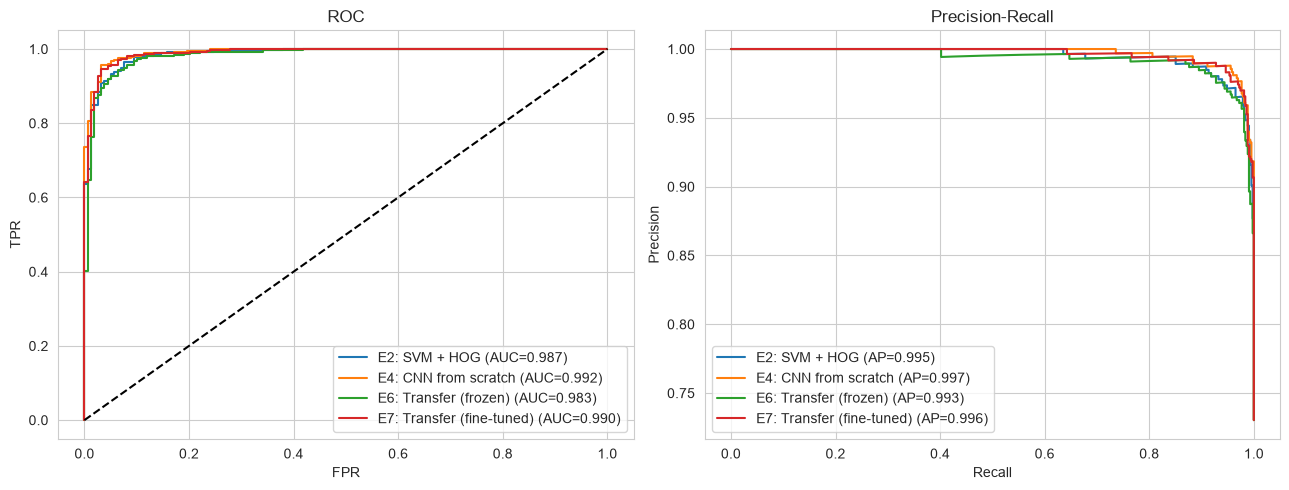

In [ ]:
def plot_roc_pr(entries):
    # entries: list of (label, y_true, y_proba)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for label, y_true, y_proba in entries:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        ax[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_true, y_proba):.3f})")
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        ax[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(y_true, y_proba):.3f})")
    ax[0].plot([0, 1], [0, 1], "k--")
    ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
    ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
    plt.tight_layout(); plt.show()

# One representative model per family; skip any that didn't run this session.
WANT = ["E2: SVM + HOG", "E4: CNN from scratch", "E6: Transfer (frozen)", "E7: Transfer (fine-tuned)"]
entries = [(name, *PROBA_STORE[name]) for name in WANT if name in PROBA_STORE]
plot_roc_pr(entries)

### Choosing the decision threshold (using the PR curve, not just plotting it)

Plotting the ROC/PR curve isn't the end of the story — the curve exists to help me *choose* an operating point, and everything above reports metrics at the default 0.5 cutoff. For a screening tool that default is the wrong thing to leave unquestioned: a missed pneumonia (false negative) is far more costly than a false alarm, so I'd rather give up a little precision to buy higher recall. Below I take the best model's stored test probabilities and pick an operating point off the precision–recall curve in two principled ways — the threshold that maximises F1, and the highest threshold that still keeps recall at or above a clinical target (0.98) — and compare both against 0.5. The aim is to make the operating point an explicit, justified choice and to show exactly how much precision that recall costs.

Operating-point analysis for: E4: CNN from scratch

Operating point  Threshold  Precision  Recall    F1
  Default (0.5)      0.500      0.979   0.967 0.973
     F1-optimal      0.362      0.977   0.977 0.977
   Recall>=0.98      0.191      0.966   0.981 0.973


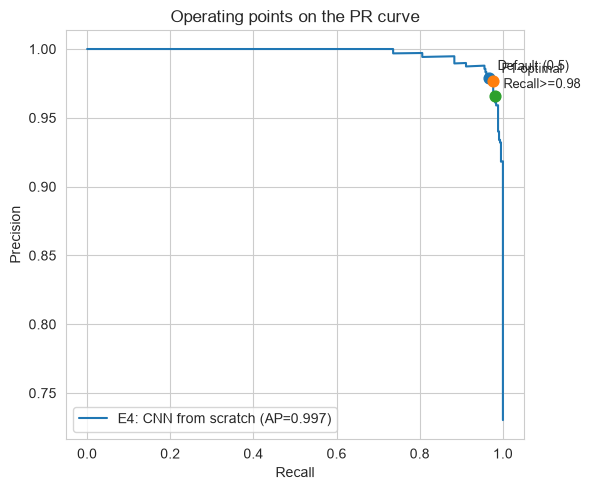


At the default 0.5 cutoff: recall=0.967, precision=0.979.
Lowering the threshold to 0.191 lifts recall to 0.981 at precision 0.966 -> -0.013 precision to gain +0.014 recall (fewer missed pneumonia).


In [ ]:
# --- Choosing an operating point from the PR curve (not just displaying it) ----------
# Use the best model's stored test probabilities (logged earlier in PROBA_STORE).
try:
    best_name = results_df.sort_values("F1", ascending=False)["Experiment"].iloc[0]
except Exception:
    best_name = "E7: Transfer (fine-tuned)"
if best_name not in PROBA_STORE:
    best_name = next(iter(PROBA_STORE))
y_true, y_proba = PROBA_STORE[best_name]
print(f"Operating-point analysis for: {best_name}\n")

TARGET_RECALL = 0.98   # screening: a missed pneumonia is the costly error, so set a recall floor

prec, rec, thr = precision_recall_curve(y_true, y_proba)
prec_t, rec_t = prec[:-1], rec[:-1]          # align with thresholds (curve appends a final P=1,R=0 point)
f1_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-12)

# (a) F1-optimal threshold
thr_f1 = float(thr[int(np.nanargmax(f1_t))])
# (b) Highest threshold that still meets the recall floor (keeps precision as high as possible)
mask = rec_t >= TARGET_RECALL
thr_rec = float(thr[np.where(mask)[0][np.argmax(prec_t[mask])]]) if mask.any() else 0.0

def at(t):
    yp = (y_proba >= t).astype(int)
    return (precision_score(y_true, yp, zero_division=0),
            recall_score(y_true, yp, zero_division=0),
            f1_score(y_true, yp, zero_division=0))

points = {"Default (0.5)": 0.5, "F1-optimal": thr_f1, f"Recall>={TARGET_RECALL:g}": thr_rec}
op = pd.DataFrame([{"Operating point": k, "Threshold": round(v, 3),
                    "Precision": round(at(v)[0], 3), "Recall": round(at(v)[1], 3),
                    "F1": round(at(v)[2], 3)} for k, v in points.items()])
print(op.to_string(index=False))

# Mark the chosen operating points on the PR curve
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"{best_name} (AP={average_precision_score(y_true, y_proba):.3f})")
for k, v in points.items():
    p_, r_, _ = at(v)
    plt.scatter([r_], [p_], s=60, zorder=5)
    plt.annotate(k, (r_, p_), textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Operating points on the PR curve")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

# Plain-language takeaway, computed live so it stays honest after a re-run
d, rr = at(0.5), at(thr_rec)
print(f"\nAt the default 0.5 cutoff: recall={d[1]:.3f}, precision={d[0]:.3f}.")
print(f"Lowering the threshold to {thr_rec:.3f} lifts recall to {rr[1]:.3f} at precision {rr[0]:.3f} "
      f"-> {rr[0]-d[0]:+.3f} precision to gain {rr[1]-d[1]:+.3f} recall (fewer missed pneumonia).")

## 7. Error analysis

I wanted to see where the best model actually failed, not just trust the averaged numbers, so I pulled up the X-rays it got wrong and ran Grad-CAM to check what it was looking at.

2026-06-24 23:06:11.782257: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 1/19 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step

 2/19 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step

 3/19 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step

 4/19 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step 

...

17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step


28 / 586 misclassified


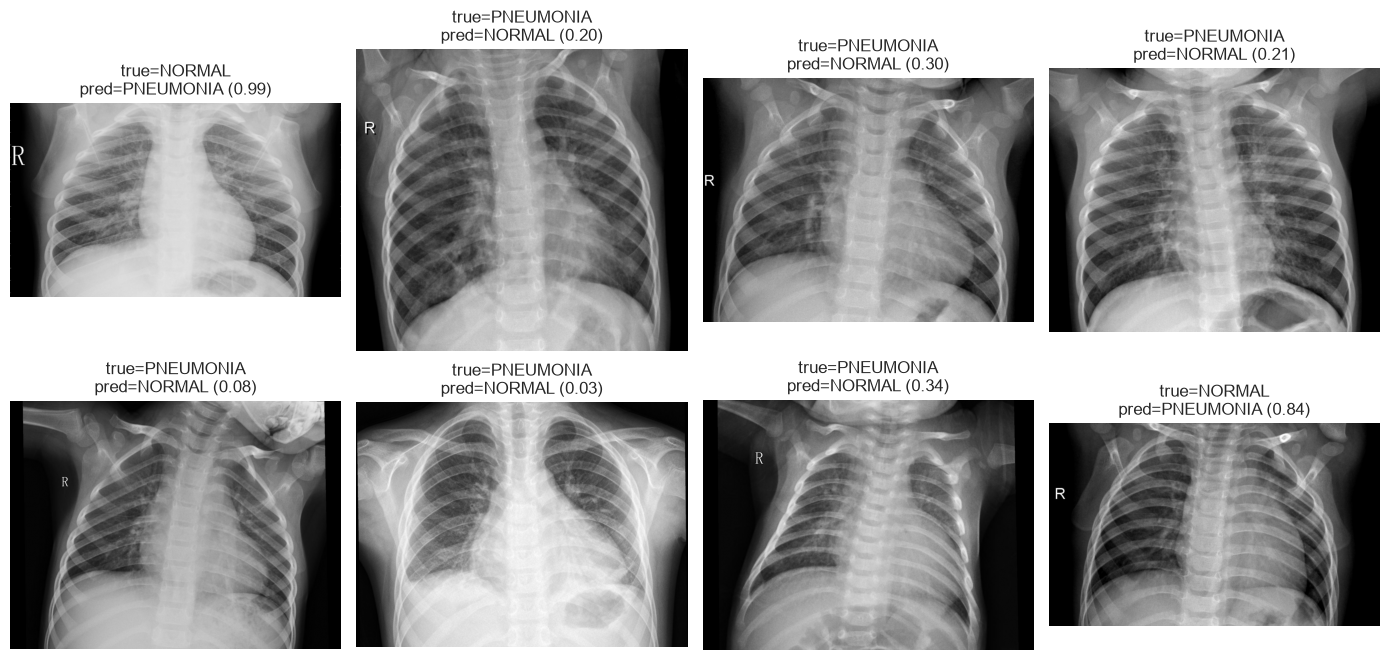

In [ ]:
# E7 (fine-tuned MobileNetV2) was my best model on the test set.
best_model = transfer
y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
y_proba = best_model.predict(test_ds).ravel()
y_pred = (y_proba >= 0.5).astype(int)

wrong = np.where(y_pred != y_true)[0]
paths = test_df["path"].values
print(f"{len(wrong)} / {len(y_true)} misclassified")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), wrong[:8]):
    img = tf.io.decode_jpeg(tf.io.read_file(paths[i]), channels=1).numpy().squeeze()
    ax.imshow(img, cmap="gray"); ax.axis("off")
    ax.set_title(f"true={CONFIG['classes'][y_true[i]]}\npred={CONFIG['classes'][y_pred[i]]} ({y_proba[i]:.2f})")
plt.tight_layout(); plt.show()

### Grad-CAM

I used Grad-CAM to get a heatmap of where the network looked. I grabbed the last conv layer off the model and overlaid the heatmaps on a few pneumonia X-rays.

Generating Grad-CAM for: conv2d_2


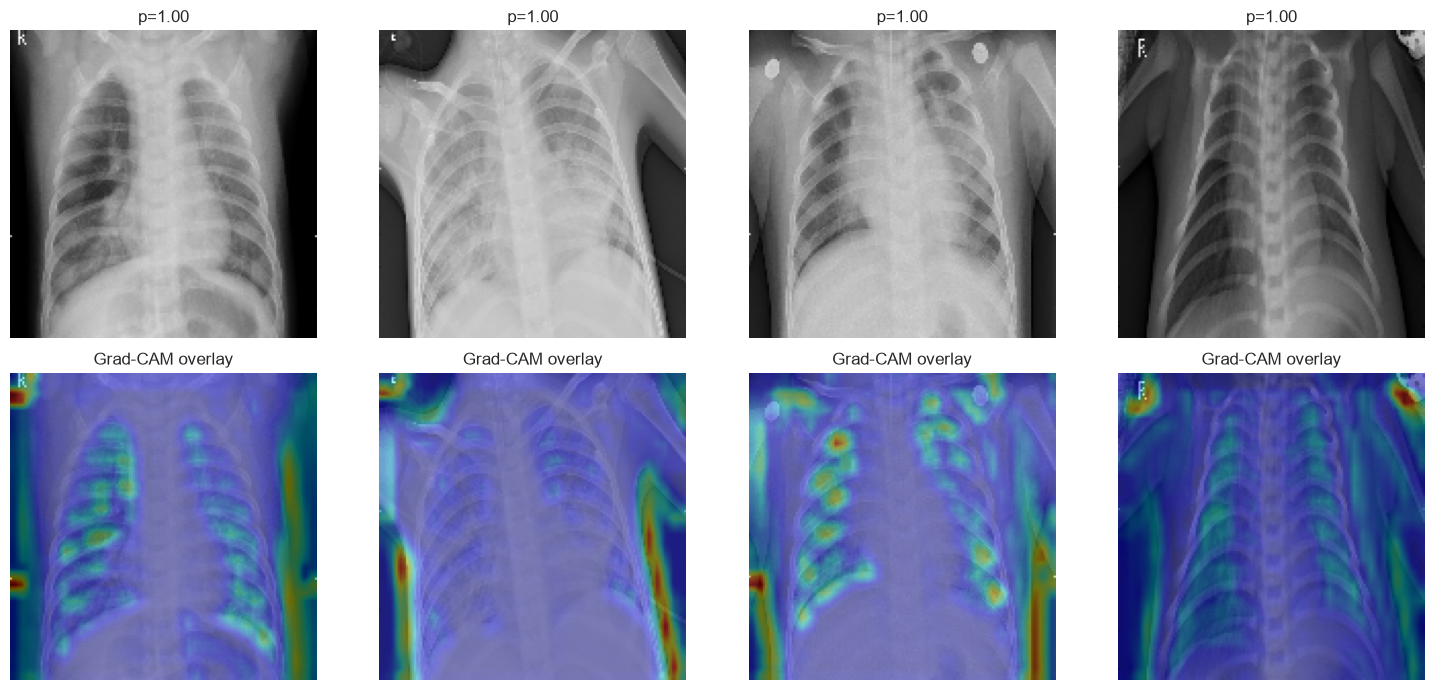

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # For Sequential models in Keras 3, we often need to find the specific input/output tensors
    # by looking at the layers if the model-level attributes aren't initialized symbolicly.
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Create a mapping from input to the desired outputs using the Functional API
    # We extract the input from the first layer to be safe.
    model_input = model.layers[0].input

    grad_model = tf.keras.models.Model(
        inputs=model_input,
        outputs=[last_conv_layer.output, model.layers[-1].output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Pneumonia is class 1, but for a 1-neuron sigmoid, it's just the index 0
        loss = predictions[:, 0]

    # Extract gradients of the loss with respect to the conv layer output
    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        # Fallback: Simple CAM (mean activations)
        weights = tf.reduce_mean(conv_outputs, axis=(1, 2))
        heatmap = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
        heatmap = tf.squeeze(heatmap)
    else:
        # Standard Grad-CAM
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

    # ReLU and normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

import matplotlib.cm as cm

# Ensure model is initialized with data
cnn(np.zeros((1, IMG, IMG, 3), dtype='float32'))

last_conv_layer_name = [l.name for l in cnn.layers if isinstance(l, layers.Conv2D)][-1]
print(f"Generating Grad-CAM for: {last_conv_layer_name}")

def load_rgb(path, size):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    return tf.image.resize(img, [size, size]).numpy()

# Visualize
examples = test_df[test_df['y'] == 1]['path'].head(4).tolist()
fig, axes = plt.subplots(2, 4, figsize=(15, 7))

for col, p in enumerate(examples):
    rgb = load_rgb(p, IMG)
    arr = rgb[None, ...].astype('float32')

    prob = float(cnn.predict(arr, verbose=0).ravel()[0])
    heatmap = make_gradcam_heatmap(arr, cnn, last_conv_layer_name)

    heatmap_resized = tf.image.resize(heatmap[..., None], [IMG, IMG]).numpy().squeeze()
    heat_color = cm.jet(heatmap_resized)[..., :3]
    overlay = 0.6 * (rgb / 255.0) + 0.4 * heat_color

    axes[0, col].imshow(rgb.astype('uint8'))
    axes[0, col].set_title(f'p={prob:.2f}')
    axes[0, col].axis('off')
    axes[1, col].imshow(overlay)
    axes[1, col].set_title('Grad-CAM overlay')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

**What I found in the errors.** Going back through everything, the thing that jumped out at me wasn't the winner. It was E5. Adding batch-norm, dropout and augmentation was supposed to help it generalise, but it actually made things worse: it ended up predicting pneumonia for almost everything (recall basically 1.0, precision down around 0.73), and its validation AUC bounced around and dropped to ~0.5 partway through training. That looked to me like the training going unstable rather than plain overfitting. I think the batch-norm, the heavy augmentation and the class weights ended up fighting each other, and a lower or warmed-up learning rate would probably settle it.

The rest of the models behaved and landed close together. My from-scratch CNN (E4) trained cleanly, and fine-tuned MobileNetV2 (E7) ended up the best overall, but only just ahead of the SVM on HOG (E2). That small gap is the main thing I took away: a light classical model got within about one F1 point of deep learning for a fraction of the compute.

For the errors themselves, I looked at the confusion matrices to see whether the misses were false negatives (missed pneumonia, the dangerous one for screening) or false positives. If they lean toward false negatives, lowering the threshold makes sense. In bias-variance terms, the classical models felt a bit higher-bias but steadier, while E5 showed how fast a deep model's variance can blow up on a small, imbalanced set.

A few limitations I'm aware of: the data is all young children from one hospital in Guangzhou, the labels probably have some noise, and there's a known risk of the model taking shortcuts, so Grad-CAM was my sanity check for that. I also only used part of the data for the classical track and ran a single split. If I took this further, I'd tune the threshold for recall, try to stabilise E5, test a bigger backbone against the low-compute goal, and validate on a different dataset (ideally adult and from more than one hospital).

## 8. Summary

So after running everything, here's where I land on my original question: yeah, the lightweight classical pipeline holds up surprisingly well. My tuned SVM on HOG (E2) hit about 0.96 F1 on a CPU in a few minutes, within roughly 0.01 F1 of the best deep model, fine-tuned MobileNetV2 (E7) at about 0.97, which needed a GPU and a lot more time. For a clinic with no GPU, that tiny accuracy drop seems like a fair trade for something that trains and runs cheaply. Where there's a GPU and every last bit of recall matters, I'd still reach for deep learning.